# IPE Simulation

International Political Economy classroom simulation.  
Collect student decisions on paper, input them below, run the engine, project results.

## Workflow each round
1. **Theory session**: Lecture on the relevant model (Ricardo, H-O, etc.)
2. **Decision session**: Hand out the printed forms from `handouts/` (see `handouts/README.md`), students deliberate and fill them in
3. **Between sessions**: Enter decisions below, run the engine
4. **Results session**: Project `sim.print_results()` and plots, discuss

## Phases (26 sessions)
- **Phase 1 (Rounds 1–3)**: Ricardian — 1 factor (labor), 2 goods (cloth, wine)
- **Phase 2 (Rounds 4–7)**: Heckscher-Ohlin — 2 factors (labor, capital), 3 goods
- **Phase 3 (Rounds 8–10)**: MNCs and varieties — firms hosted abroad; CES variety preference
- **Phase 4 (Rounds 11–14)**: Firm heterogeneity — productivity draws, fixed export costs, structural shock, populist backlash
- **Phase 5 (Rounds 15–20)**: Money & FX — currencies, the trilemma, speculative attacks, monetary unions
- **Phase 6 (Rounds 21–22)**: Sovereign debt — borrowing, original sin, default, IMF
- **Phase 7 (Rounds 23–26)**: Institutions & capstone — WTO, hegemonic stability, side payments, hegemonic challenge

In [1]:
import json
from engine import (
    IPESimulation,
    PHASE1_COUNTRIES, PHASE1_GOODS,
    PHASE2_COUNTRIES, PHASE2_GOODS,
    PHASE3_FIRMS,
)

# Create the simulation — Phase 1
sim = IPESimulation(PHASE1_COUNTRIES, PHASE1_GOODS, phase=1)

---
## Country Briefs
Print these out or project for students at the start of the simulation.

**Country briefs → printed handout.** Instructions are now **`handouts/country-briefs.pdf`** (one page per country; hand to each group once — they keep it). On-screen fallback: `sim.print_country_briefs()`.

## Decision Forms
Print and distribute to each team. Each country gets its own form
with their endowments pre-filled.

**Forms → printed handout.** Hand out **`handouts/forms-phase1-ricardo.pdf`** (one per group; the blank `ROUND ___` field works for any round). On-screen fallback: `sim.print_decision_forms()`.

---
---
# Phase 1: Ricardian Trade

## Round 1 — Autarky Baseline

First round: no trade allowed. Students just choose how to allocate labor.
This establishes a welfare baseline and forces them to confront the
production possibility frontier.

In [4]:
# ═══════════════════════════════════════════════════
#  ROUND 1 — Enter student decisions below
# ═══════════════════════════════════════════════════
# Fill in from student decision forms. Each row must sum to the
# country's labor endowment (shown in the comment).
# No tariffs or trades in Round 1 (autarky).

round1_decisions = {
    "Brazos":  {"production": {"cloth": 150, "wine": 0}},   # must sum to 150
    "Bosque":  {"production": {"cloth": 60, "wine": 0}},   # must sum to  60
    "Llano":  {"production": {"cloth": 100, "wine": 0}},   # must sum to 100
    "Trinity":  {"production": {"cloth": 0, "wine": 120}},   # must sum to 120
    "Pecos":  {"production": {"cloth": 0, "wine": 50}},   # must sum to  50
    "Sabine": {"production": {"cloth": 0, "wine": 100}},   # must sum to 100
}

round1_trades = []  # No trade in round 1

result = sim.run_round(round1_decisions, round1_trades)
sim.print_results()


  ROUND 1 RESULTS  --  Phase 1

  PRODUCTION
                         cloth        wine
                         -----       -----
  Brazos                 300.0         0.0
  Bosque                 240.0         0.0
  Llano                  100.0         0.0
  Trinity                  0.0       180.0
  Pecos                    0.0       175.0
  Sabine                   0.0       150.0

  TRADES
  (no trades this round)

  CONSUMPTION & WELFARE
                         cloth        wine     Welfare vs No Trade
                         -----       -----       -----       -----
  Brazos                 300.0         0.0         0.0+       0.0%
  Bosque                 240.0         0.0         0.0+       0.0%
  Llano                  100.0         0.0         0.0+       0.0%
  Trinity                  0.0       180.0         0.0+       0.0%
  Pecos                    0.0       175.0         0.0+       0.0%
  Sabine                   0.0       150.0         0.0+       0.0%




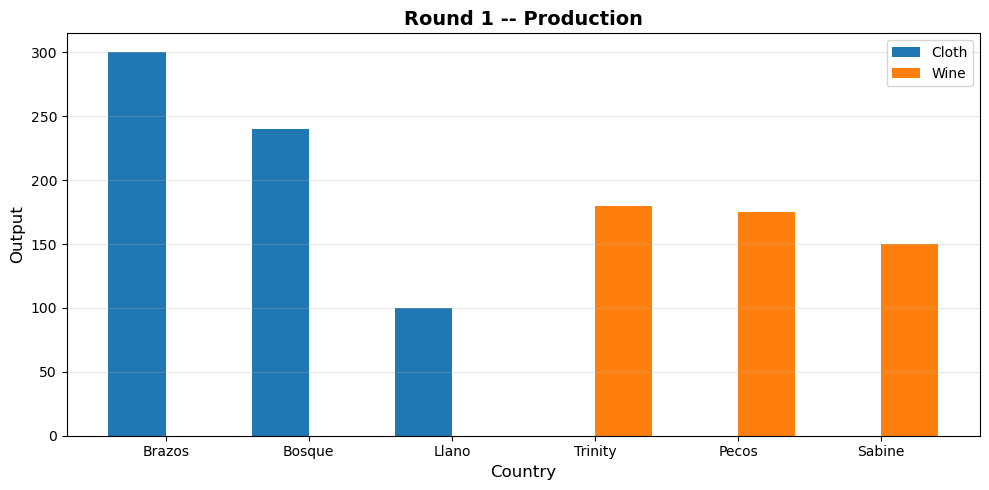

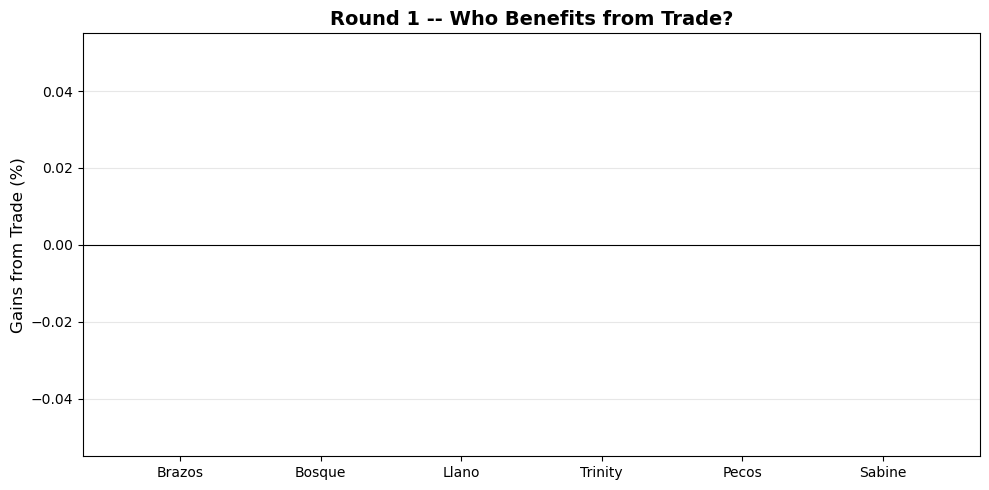

In [5]:
sim.plot_production()
sim.plot_gains_from_trade()

## Round 2 — Trade Opens

Now students can trade. They negotiate in class and write offers on
their decision forms. You mediate: if both sides agree on terms, the
trade goes through. Enter only the agreed-upon trades.

In [6]:
# ═══════════════════════════════════════════════════
#  ROUND 2 — Enter decisions and agreed trades
# ═══════════════════════════════════════════════════

round2_decisions = {
    "Brazos":  {"production": {"cloth": 75, "wine": 75}},
    "Bosque":  {"production": {"cloth": 50, "wine": 10}},   # specializing!
    "Llano":  {"production": {"cloth": 20, "wine": 80}},   # specializing!
    "Trinity":  {"production": {"cloth": 80, "wine": 40}},
    "Pecos":  {"production": {"cloth": 25, "wine": 25}},
    "Sabine": {"production": {"cloth": 30, "wine": 70}},
}

# Agreed trades: (exporter, importer, good_out, qty_out, good_in, qty_in)
round2_trades = [
    # Bosque sends cloth to Llano for wine
    ("Bosque", "Llano", "cloth", 80, "wine", 50),
    # Trinity sends cloth to Sabine for wine
    ("Trinity", "Sabine", "cloth", 40, "wine", 30),
]

result = sim.run_round(round2_decisions, round2_trades)
sim.print_results()


  ROUND 2 RESULTS  --  Phase 1

  PRODUCTION
                         cloth        wine
                         -----       -----
  Brazos                 150.0       150.0
  Bosque                 200.0        10.0
  Llano                   20.0       240.0
  Trinity                240.0        60.0
  Pecos                   87.5        87.5
  Sabine                  30.0       105.0

  TRADES
  Bosque -> Llano: 80 cloth for 50 wine  [ToT: 1 cloth = 0.62 wine]
  Trinity -> Sabine: 40 cloth for 30 wine  [ToT: 1 cloth = 0.75 wine]

  CONSUMPTION & WELFARE
                         cloth        wine     Welfare vs No Trade
                         -----       -----       -----       -----
  Brazos                 150.0       150.0       150.0+       0.0%
  Bosque                 120.0        60.0        84.9+      89.7%
  Llano                  100.0       190.0       137.8+      99.0%
  Trinity                200.0        90.0       134.2+      11.8%
  Pecos                   87.5     

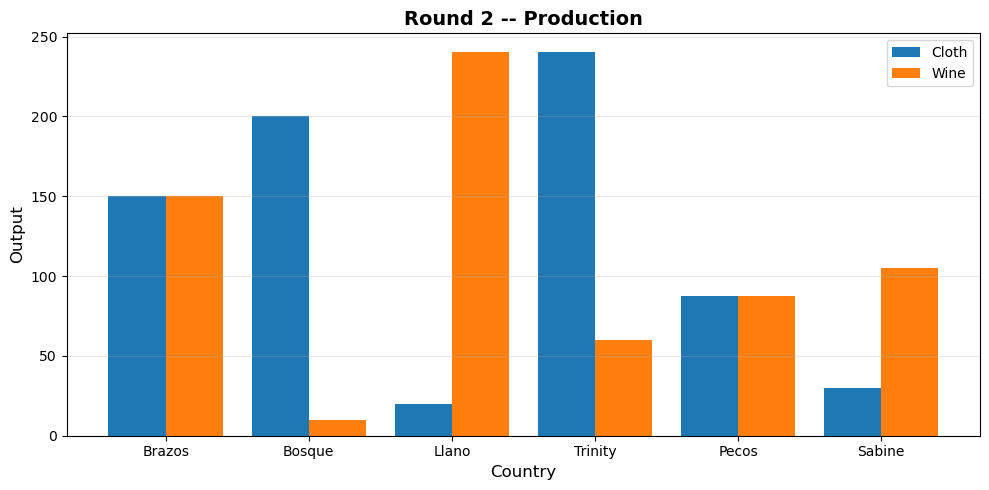

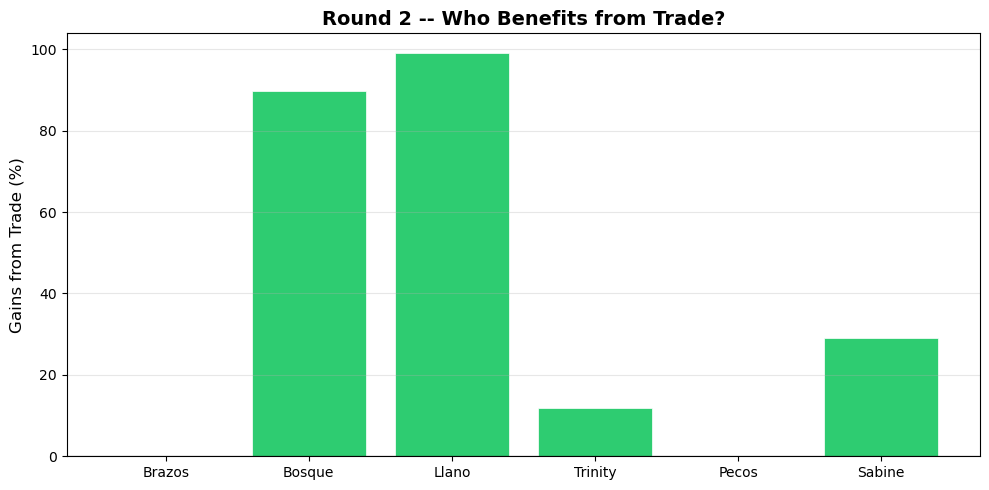

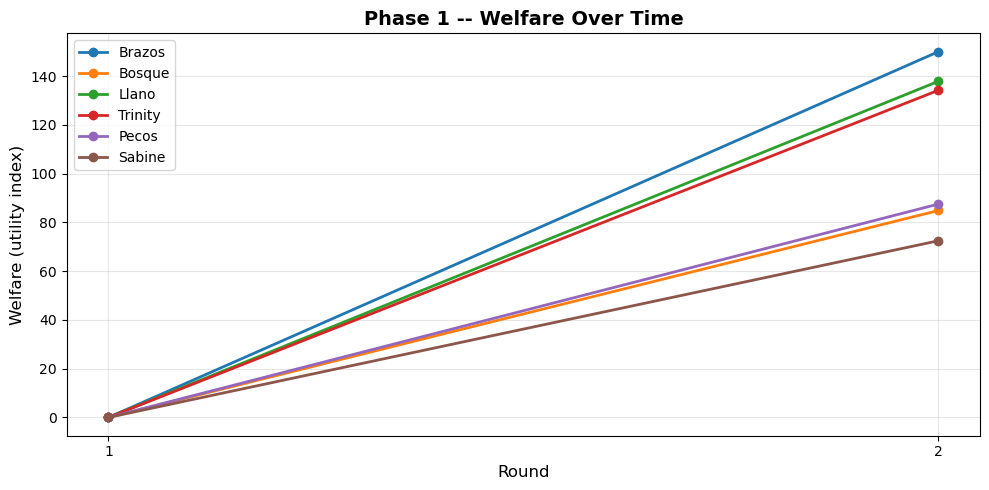

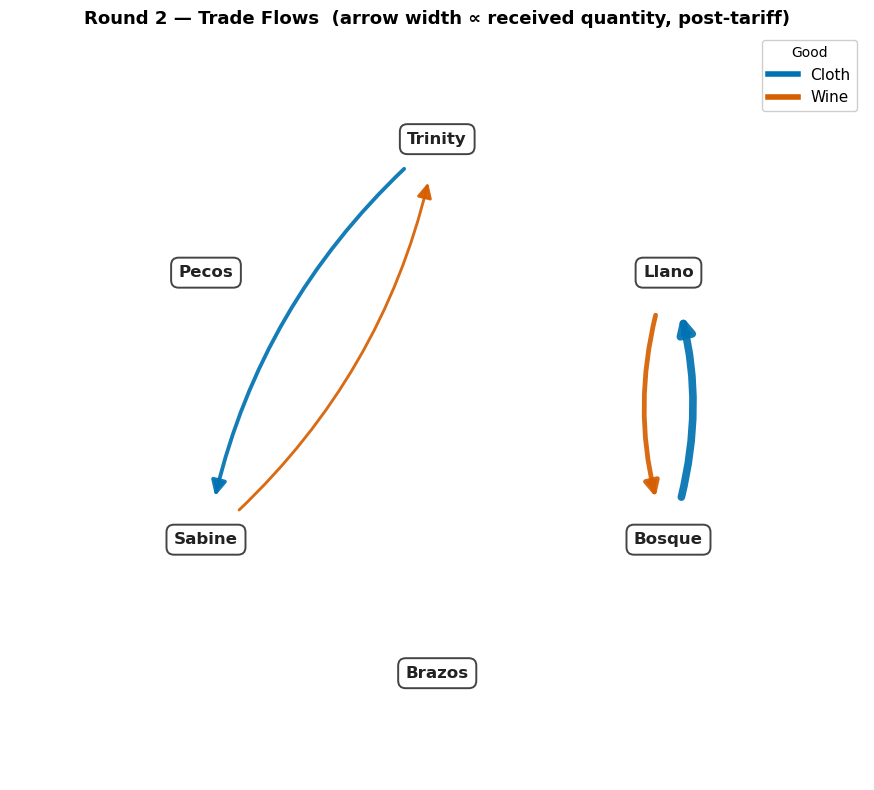

In [7]:
sim.plot_production()
sim.plot_gains_from_trade()
sim.plot_welfare()
sim.plot_trade_network()

## Round 3 — Tariffs Activated

Students can now set tariffs on imports from specific countries.
Tariff = fraction of imports destroyed (deadweight loss).
This is a simplification — discuss the full picture in the debrief.

Key questions for discussion:
- Who set tariffs and why?
- Did tariffs change trade patterns?
- Is anyone better off with tariffs? Worse off?

In [8]:
# ═══════════════════════════════════════════════════
#  ROUND 3 — With tariffs
# ═══════════════════════════════════════════════════

round3_decisions = {
    "Brazos": {
        "production": {"cloth": 75, "wine": 75},
        "tariffs": {},  # free trader
    },
    "Bosque": {
        "production": {"cloth": 55, "wine": 5},
        "tariffs": {},
    },
    "Llano": {
        "production": {"cloth": 10, "wine": 90},
        "tariffs": {
            "Bosque": {"cloth": 0.15},  # 15% tariff on Bosque's cloth!
        },
    },
    "Trinity": {
        "production": {"cloth": 90, "wine": 30},
        "tariffs": {},
    },
    "Pecos": {
        "production": {"cloth": 30, "wine": 20},
        "tariffs": {},
    },
    "Sabine": {
        "production": {"cloth": 20, "wine": 80},
        "tariffs": {
            "Trinity": {"cloth": 0.20},  # 20% tariff on Trinity's cloth
        },
    },
}

round3_trades = [
    ("Bosque", "Llano", "cloth", 100, "wine", 60),
    ("Trinity", "Sabine", "cloth", 50, "wine", 40),
    ("Pecos", "Brazos", "cloth", 30, "wine", 25),
]

result = sim.run_round(round3_decisions, round3_trades)
sim.print_results()


  ROUND 3 RESULTS  --  Phase 1

  PRODUCTION
                         cloth        wine
                         -----       -----
  Brazos                 150.0       150.0
  Bosque                 220.0         5.0
  Llano                   10.0       270.0
  Trinity                270.0        45.0
  Pecos                  105.0        70.0
  Sabine                  20.0       120.0

  TRADES
  Bosque -> Llano: 100 cloth for 60 wine  [ToT: 1 cloth = 0.60 wine] [tariffs: 15% on cloth, 0% on wine]
  Trinity -> Sabine: 50 cloth for 40 wine  [ToT: 1 cloth = 0.80 wine] [tariffs: 20% on cloth, 0% on wine]
  Pecos -> Brazos: 30 cloth for 25 wine  [ToT: 1 cloth = 0.83 wine]

  CONSUMPTION & WELFARE
                         cloth        wine     Welfare vs No Trade
                         -----       -----       -----       -----
  Brazos                 180.0       125.0       150.0+       0.0%
  Bosque                 120.0        65.0        88.3+     166.3%
  Llano                   95

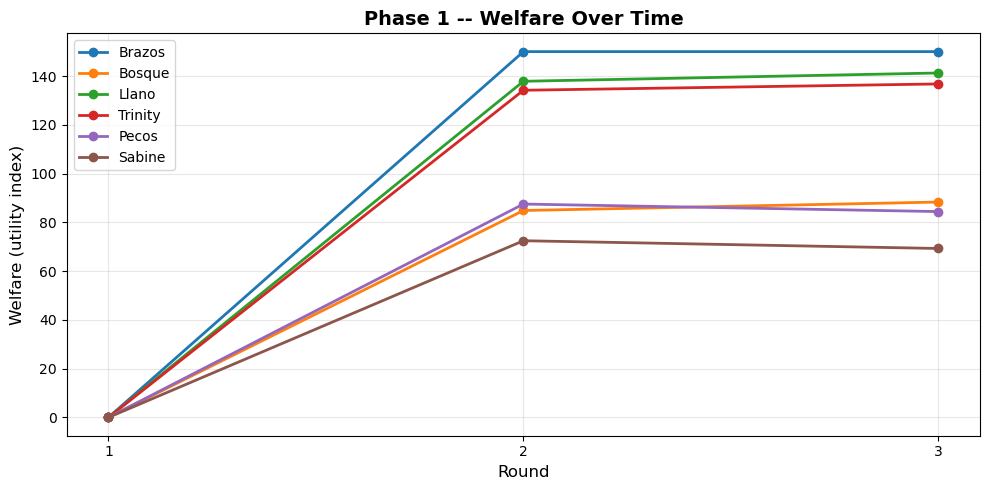

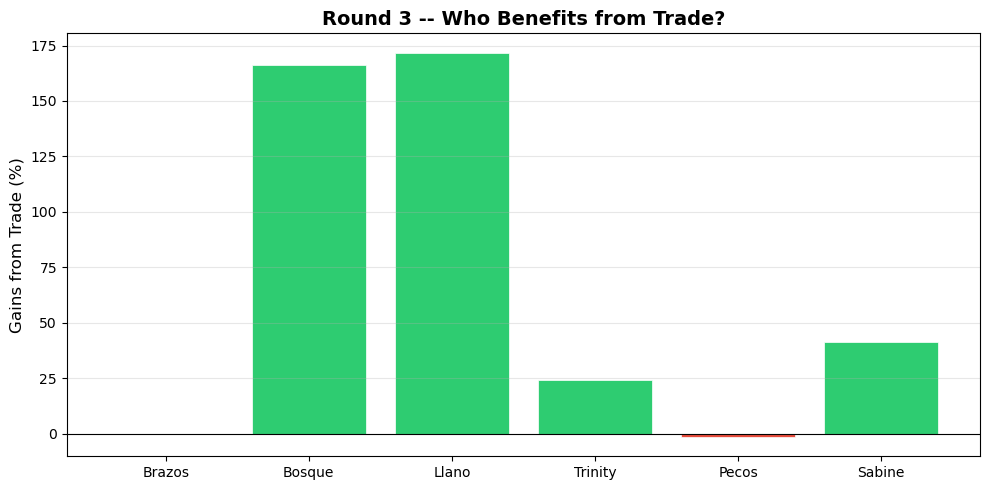

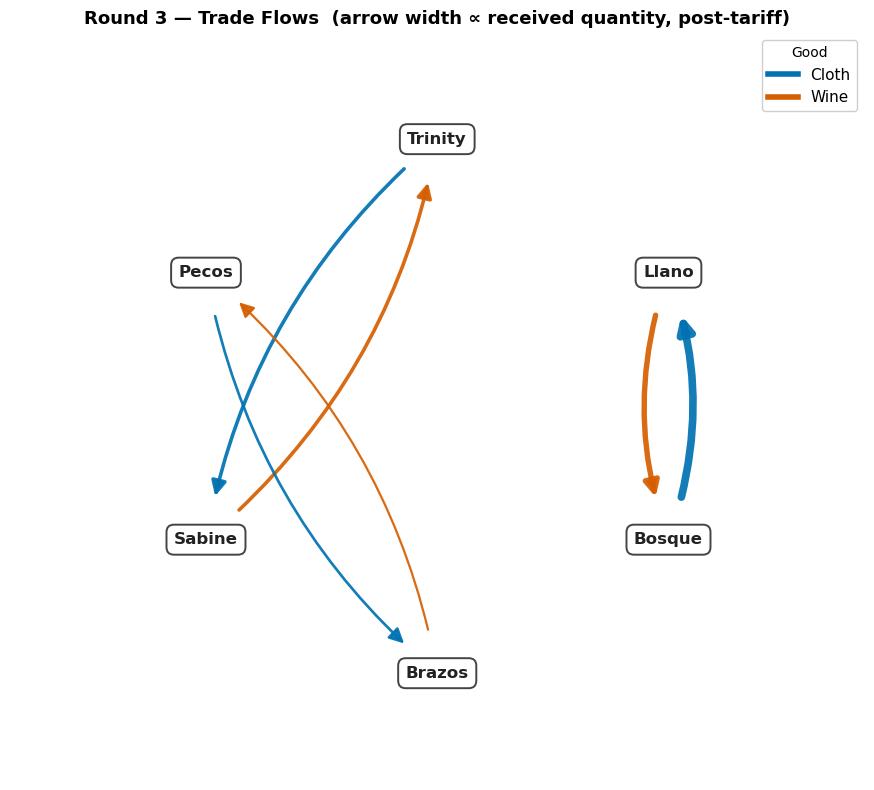

In [9]:
sim.plot_welfare()
sim.plot_gains_from_trade()
sim.plot_trade_network()

---
## Instructor: Inject a Shock (optional)

Between rounds, you can modify country parameters to simulate
technology changes, resource discoveries, natural disasters, etc.

In [ ]:
# Example: Llano's wine productivity crashes (drought)
# Uncomment to use:

# sim.inject_shock("Severe drought hits Llano's vineyards", {
#     "Llano": {"productivity": {"wine": 1.5}}  # was 3.0
# })

---
---
# Phase 2: Heckscher-Ohlin

Upgrade the simulation. Countries now have **labor and capital**.
A third good (**machinery**) is added — it's capital-intensive.

Key concepts that emerge:
- Labor-abundant countries specialize in labor-intensive goods
- Capital-abundant countries specialize in capital-intensive goods
- **Trade creates winners and losers within countries** (Stolper-Samuelson)
- Factor prices (wages vs. returns to capital) now diverge

In [ ]:
# Upgrade to Phase 2 — keeps all prior history
sim.upgrade_to_phase2(PHASE2_COUNTRIES, PHASE2_GOODS)
# Country briefs are now a handout: handouts/country-briefs.pdf

**Phase 2 forms → printed handout.** Hand out **`handouts/forms-phase2plus-trade.pdf`** (labor + capital across three goods; reused for every later trade round). On-screen fallback: `sim.print_decision_forms()`.

## Round 4 — First H-O Round (Autarky)

No trade first round of Phase 2. Students allocate BOTH labor and capital.
Watch the factor prices — who earns more, workers or capitalists?

In [ ]:
# ═══════════════════════════════════════════════════
#  ROUND 4 — Phase 2 autarky baseline
# ═══════════════════════════════════════════════════
# Fill in from student decision forms.
# Labor row must sum to the country's labor endowment.
# Capital row must sum to the country's capital endowment.
# A sector needs BOTH factors to produce output (Cobb-Douglas).

round4_decisions = {
    "Brazos": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 150
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 150
        },
    },
    "Bosque": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  60
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  25
        },
    },
    "Llano": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 100
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  80
        },
    },
    "Trinity": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 120
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 200
        },
    },
    "Pecos": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  50
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 120
        },
    },
    "Sabine": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 100
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  35
        },
    },
}

round4_trades = []  # Autarky round

result = sim.run_round(round4_decisions, round4_trades)
sim.print_results()

In [ ]:
sim.plot_production()
sim.plot_welfare()

## Round 5+ — H-O with Trade

Copy the template below for each subsequent round.
Now watch for:
- Do labor-abundant countries (Bosque, Sabine) export cloth?
- Do capital-abundant countries (Trinity, Pecos) export machinery?
- How do wages vs. returns to capital change when trade opens?
- Who demands tariffs — workers in capital-rich countries? Capitalists in labor-rich ones?

In [ ]:
# ═══════════════════════════════════════════════════
#  ROUND 5
# ═══════════════════════════════════════════════════

roundN_decisions = {
    "Brazos": {
        "production": {
            "labor":   {"cloth": 50, "wine": 50, "machinery": 50},
            "capital":  {"cloth": 50, "wine": 50, "machinery": 50},
        },
        "tariffs": {},  # e.g. {"Bosque": {"cloth": 0.10}}
    },
    "Bosque": {
        "production": {
            "labor":   {"cloth": 30, "wine": 15, "machinery": 15},
            "capital":  {"cloth": 10, "wine": 8,  "machinery": 7},
        },
        "tariffs": {},
    },
    "Llano": {
        "production": {
            "labor":   {"cloth": 25, "wine": 50, "machinery": 25},
            "capital":  {"cloth": 20, "wine": 35, "machinery": 25},
        },
        "tariffs": {},
    },
    "Trinity": {
        "production": {
            "labor":   {"cloth": 30, "wine": 30, "machinery": 60},
            "capital":  {"cloth": 40, "wine": 40, "machinery": 120},
        },
        "tariffs": {},
    },
    "Pecos": {
        "production": {
            "labor":   {"cloth": 10, "wine": 15, "machinery": 25},
            "capital":  {"cloth": 20, "wine": 30, "machinery": 70},
        },
        "tariffs": {},
    },
    "Sabine": {
        "production": {
            "labor":   {"cloth": 50, "wine": 35, "machinery": 15},
            "capital":  {"cloth": 15, "wine": 12, "machinery": 8},
        },
        "tariffs": {},
    },
}

roundN_trades = [
    # (exporter, importer, good_out, qty_out, good_in, qty_in)
    # ("Bosque", "Trinity", "cloth", 40, "machinery", 25),
]

# result = sim.run_round(roundN_decisions, roundN_trades)
# sim.print_results()

---
---
# Phase 3: MNCs and New Trade Theory

Upgrade the simulation. Countries now share the global economy with **multinational corporations (MNCs)**.

Each firm:
- belongs to a specific **industry** (cloth / wine / machinery)
- produces a unique **variety** within its industry
- is **hosted in one country** (where it produces) but **owned by a student from a different country**

Two new things happen:

1. **Love-of-variety** enters utility (CES nest inside Cobb-Douglas). Having access to more varieties of cloth raises cloth-utility even holding total cloth constant. This is the Krugman gains-from-trade *on top of* the Ricardo/H-O gains.
2. **Divided loyalty**: each student plays both a country-team member (cares about country welfare) and an MNC owner (cares about firm profit). These interests rarely align. Final score weights both equally.

### Country-side decisions
Same as Phase 2: allocate labor and capital across cloth, wine, machinery; set tariffs; agree trades.

### MNC-side decisions (new)
For each firm, the owner decides each round:
- **`scale`**: units to produce, 0 to `max_scale`
- **`relocate_to`**: another country to move to (output is 0 this round; firm lives in new host next round)
- **`export`** (Phase 4 only): whether to incur the fixed export cost

In [ ]:
# Upgrade to Phase 3 — keeps all prior history
# Default: load all 13 firms from PHASE3_FIRMS. For exactly 10 students,
# pass a subset (F1-F10) so each student owns one firm.

firms_for_class = {fid: PHASE3_FIRMS[fid] for fid in
                   ["F1","F2","F3","F4","F5","F6","F7","F8","F9","F10"]}
# If you have 11-13 students, add slack firms F11, F12, F13 as needed:
# firms_for_class["F11"] = PHASE3_FIRMS["F11"]

sim.upgrade_to_phase3(firms_for_class)

## MNC Roster
Show the firm table. Use this to assign each student one MNC (whose host country ≠ that student's country team). Hand-pick matchups to maximize divided-loyalty drama where you can.

In [ ]:
sim.print_firm_roster()
sim.plot_firm_locations()

## Decision Forms — Phase 3
Two stacks to print: country-team forms (same as Phase 2) and firm forms (one per MNC owner).

**Phase 3 forms → printed handouts.**

- Country teams: **`handouts/forms-phase2plus-trade.pdf`** (same shape as Phase 2)
- MNC owners: **`handouts/forms-firms.pdf`** (one boxed form per firm; the export line activates in Phase 4)

On-screen fallback: `sim.print_decision_forms()`, `sim.print_firm_decision_forms()`.

## Round 8 — First Phase 3 Round (MNCs go live)

Countries solicit MNCs with tax-break and subsidy offers (negotiated in the room; you don't need to encode them — they show up as relocations or scale changes).

Watch for:
- Where do MNCs cluster? Does it match comparative advantage?
- Which countries' welfare jumps from variety gains?
- Are owners helping their *firm* or their *country* — and when do those conflict?

In [ ]:
# ═══════════════════════════════════════════════════
#  ROUND 8 — Phase 3 first round
# ═══════════════════════════════════════════════════
# Fill in country decisions (same shape as Phase 2) AND firm decisions.

round8_decisions = {
    "Brazos": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 150
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 150
        },
        "tariffs": {},
    },
    "Bosque": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  60
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  25
        },
        "tariffs": {},
    },
    "Llano": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 100
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  80
        },
        "tariffs": {},
    },
    "Trinity": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 120
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 200
        },
        "tariffs": {},
    },
    "Pecos": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  50
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 120
        },
        "tariffs": {},
    },
    "Sabine": {
        "production": {
            "labor":   {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to 100
            "capital": {"cloth": 0, "wine": 0, "machinery": 0},   # must sum to  35
        },
        "tariffs": {},
    },
}

# MNC decisions: scale in [0, max_scale=40], relocate_to=None to stay.
round8_firm_decisions = {
    "F1":  {"scale": 0, "relocate_to": None, "export": False},  # Cloth-A in Bosque
    "F2":  {"scale": 0, "relocate_to": None, "export": False},  # Cloth-B in Llano
    "F3":  {"scale": 0, "relocate_to": None, "export": False},  # Cloth-C in Sabine
    "F4":  {"scale": 0, "relocate_to": None, "export": False},  # Wine-A in Llano
    "F5":  {"scale": 0, "relocate_to": None, "export": False},  # Wine-B in Sabine
    "F6":  {"scale": 0, "relocate_to": None, "export": False},  # Wine-C in Brazos
    "F7":  {"scale": 0, "relocate_to": None, "export": False},  # Mach-A in Trinity
    "F8":  {"scale": 0, "relocate_to": None, "export": False},  # Mach-B in Pecos
    "F9":  {"scale": 0, "relocate_to": None, "export": False},  # Mach-C in Brazos
    "F10": {"scale": 0, "relocate_to": None, "export": False},  # Mach-D in Trinity
}

round8_trades = []  # No trade first Phase 3 round; let MNCs settle in

result = sim.run_round(round8_decisions, round8_trades,
                       firm_decisions=round8_firm_decisions)
sim.print_results()

In [ ]:
sim.plot_production()
sim.plot_welfare()
sim.plot_firm_locations()        # see where MNCs cluster
sim.plot_trade_network()         # rich once trade opens in R9+

## Round 9+ — Phase 3 / 4 template

Copy this cell for each subsequent round. In **Phase 4** (Round 11 onward), set `sim.phase = 4` once and from then on toggle `"export"` per firm to incur the fixed export cost — low-productivity firms will lose money exporting, which is the Melitz selection point.

In [ ]:
# ═══════════════════════════════════════════════════
#  ROUND N — Phase 3 / 4 template
# ═══════════════════════════════════════════════════
# To enter Phase 4 (Round 11+):  uncomment the next line, once.
# sim.phase = 4

roundN_decisions = {
    "Brazos": {
        "production": {
            "labor":   {"cloth": 50, "wine": 50, "machinery": 50},
            "capital": {"cloth": 50, "wine": 50, "machinery": 50},
        },
        "tariffs": {},
    },
    "Bosque": {
        "production": {
            "labor":   {"cloth": 30, "wine": 15, "machinery": 15},
            "capital": {"cloth": 10, "wine": 8,  "machinery": 7},
        },
        "tariffs": {},
    },
    "Llano": {
        "production": {
            "labor":   {"cloth": 25, "wine": 50, "machinery": 25},
            "capital": {"cloth": 20, "wine": 35, "machinery": 25},
        },
        "tariffs": {},
    },
    "Trinity": {
        "production": {
            "labor":   {"cloth": 30, "wine": 30, "machinery": 60},
            "capital": {"cloth": 40, "wine": 40, "machinery": 120},
        },
        "tariffs": {},
    },
    "Pecos": {
        "production": {
            "labor":   {"cloth": 10, "wine": 15, "machinery": 25},
            "capital": {"cloth": 20, "wine": 30, "machinery": 70},
        },
        "tariffs": {},
    },
    "Sabine": {
        "production": {
            "labor":   {"cloth": 50, "wine": 35, "machinery": 15},
            "capital": {"cloth": 15, "wine": 12, "machinery": 8},
        },
        "tariffs": {},
    },
}

roundN_firm_decisions = {
    "F1":  {"scale": 30, "relocate_to": None, "export": False},
    "F2":  {"scale": 30, "relocate_to": None, "export": False},
    "F3":  {"scale": 30, "relocate_to": None, "export": False},
    "F4":  {"scale": 30, "relocate_to": None, "export": False},
    "F5":  {"scale": 30, "relocate_to": None, "export": False},
    "F6":  {"scale": 30, "relocate_to": None, "export": False},
    "F7":  {"scale": 30, "relocate_to": None, "export": False},
    "F8":  {"scale": 30, "relocate_to": None, "export": False},
    "F9":  {"scale": 30, "relocate_to": None, "export": False},
    "F10": {"scale": 30, "relocate_to": None, "export": False},
}

roundN_trades = [
    # (exporter, importer, good_out, qty_out, good_in, qty_in)
    # ("Bosque", "Trinity", "cloth", 40, "machinery", 25),
]

# result = sim.run_round(roundN_decisions, roundN_trades,
#                        firm_decisions=roundN_firm_decisions)
# sim.print_results()

---
---
# Phase 4: New-New Trade Theory (Heterogeneous Firms)

Activate Phase 4 by toggling `sim.phase = 4` (see the Round 9+ template above). Once active:

- The `export` flag on each firm becomes meaningful — setting it `True` charges the firm its `fixed_export_cost`. **High-productivity firms profit from exporting; low-productivity firms lose money.** That is Melitz selection.
- Populist regimes via `inject_populist_backlash()` — tariff floor on imports + MNC tax on revenue earned in that country. The tax goes to a **separate ledger** and does *not* enter welfare.
- Structural productivity shocks via `inject_productivity_surge()` — frame however the lecture needs (automation, ML, foreign cost collapse). Same mechanic regardless.

| Round | Move |
|---|---|
| 11 | First Phase 4 round — Melitz selection into exporting |
| 12 | Structural productivity shock in one country/industry |
| 13 | Populist backlash in a shocked country |
| 14 | Trade-era finale: award reserve currency + firm rankings |

## Round 12 — Structural Productivity Shock

Inject a productivity surge in one country/industry **before** running Round 14. Frame it however you like — the mechanic is identical. Then run Round 14 via the Phase 3/4 template (with `sim.phase = 4`).

In [ ]:
# Examples — uncomment one, pick country+industry, set the framing.
# sim.inject_productivity_surge(
#     "Pecos", "machinery", 2.5,
#     description="Automation breakthrough doubles Pecos factory output")
# sim.inject_productivity_surge(
#     "Bosque", "cloth", 1.8,
#     description="ML-driven looms raise Bosque textile productivity")

## Round 13 — Populist Backlash

After the shock, a losing country swings populist. `inject_populist_backlash()` sets a `tariff_floor` (minimum on all imports) plus an `mnc_tax_rate` (on MNC revenue; separate ledger, **does not enter welfare**). Debrief: the state collected real money — where does it go? The engine refuses to answer.

In [ ]:
# sim.inject_populist_backlash("Sabine",
#     description="Populist sweep in Sabine after the productivity shock")
# sim.inject_populist_backlash("Bosque", tariff_floor=0.40, mnc_tax_rate=0.25,
#     description="Hard-protectionist coalition takes power in Bosque")
# Reverse later:
# sim.inject_shock("Reform government lifts barriers",
#     {"Sabine": {"tariff_floor": 0.0, "mnc_tax_rate": 0.0}})

## Round 14 — Trade-Era Finale

Run Round 16 as a normal round first, *then* the ceremony below: the top cumulative-welfare country (Phase 4 tiebreaker) wins the reserve currency and becomes the Phase 5/6 hegemon. Each student sees their firm's profit rank.

In [ ]:
ranking = sim.award_reserve_currency()
sim.print_firm_rankings()

---
---
# Phase 5: Money & FX (the Trilemma)

Each country gets its own currency. Every round it picks three switches plus a money-growth rate:

- **`fx_regime`**: `"peg"` (fixed to the reserve currency), `"managed"`, or `"float"`
- **`capital_controls`**: `True` (closed) or `False` (open)
- **`independent_monetary`**: `True` (sets own `money_supply_growth`) or `False` (passive)
- **`money_supply_growth`**: one of `0.0, 0.02, 0.05, 0.10` (only used if independent)

**The trilemma (graduated stress):** running `peg` + open capital + independent money simultaneously is *overreach*. One overreach round → **warning** (currency slips 10%). A second consecutive overreach → **full crisis** (30% devaluation + 10% welfare hit), then stress resets. Any round you pick only 2-of-3, stress clears.

**FX friction** stacks on tariffs: trades involving the **reserve currency holder** = 0% friction; same-**monetary-union** members = 0% friction; otherwise 2% baseline, +3% if a party was just warned.

**MNC profits accrue in host currency** — a firm in a depreciating or crisis-hit host keeps less real value.

The reserve currency holder (from the Phase 4 ceremony) becomes the Phase 6 hegemon.

In [ ]:
# Requires award_reserve_currency() to have run (end of Phase 4).
sim.upgrade_to_phase5()
sim.print_monetary_dashboard()

## Round 15 — First Regime Choice

Each country (or monetary union) submits a `monetary_decisions` entry. Omitted countries keep their current policy. Watch who overreaches.

In [ ]:
# ═══════════════════════════════════════════════════
#  ROUND 15 — Phase 5 first monetary round
# ═══════════════════════════════════════════════════
# Country production/trade decisions are the same shape as the Phase 3/4
# template. Add monetary_decisions. Defaults below are the SAFE managed float.

round15_monetary = {
    "Brazos":  {"fx_regime": "managed", "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},
    "Bosque":  {"fx_regime": "managed", "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},
    "Llano":   {"fx_regime": "managed", "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},
    "Trinity": {"fx_regime": "managed", "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},
    "Pecos":   {"fx_regime": "managed", "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},
    "Sabine":  {"fx_regime": "managed", "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},
}

# Reuse roundN_decisions / roundN_firm_decisions from the Phase 3/4 template.
# result = sim.run_round(roundN_decisions, roundN_trades,
#                        firm_decisions=roundN_firm_decisions,
#                        monetary_decisions=round15_monetary)
# sim.print_results()
# sim.print_monetary_dashboard()

## Mid-phase moves (R16–R20)

Instructor events, one per round. Uncomment as needed before running each round.

- **R16 monetary divergence** — force a country to print
- **R17 speculative attack** — let the stress accumulator fire, or trigger manually
- **R18 monetary union** — students form a union
- **R19 asymmetric shock** — productivity surge on one union member only
- **R20 capital flight** — sudden outflow

In [ ]:
# R16: force printing
# sim.inject_monetary_shock("Sabine", 0.10,
#     description="Fiscal pressure forces Sabine to print")

# R17: manual attack (safety valve if stress pacing doesn't line up with class)
# sim.inject_speculative_attack("Bosque")

# R18: form a monetary union (members then submit IDENTICAL monetary_decisions)
# sim.form_monetary_union("Bosque", "Pecos", name="Bosque-Pecos Union")

# R19: asymmetric shock to one union member
# sim.inject_productivity_surge("Bosque", "cloth", 1.8,
#     description="Boom in Bosque stresses the shared currency")

# R20: capital flight
# sim.inject_capital_flight("Pecos", severity=0.6,
#     description="Capital flight from Pecos amid instability")

# Dissolve a union later if desired:
# sim.dissolve_monetary_union("Bosque-Pecos Union")

## Round N — Phase 5 template

Copy for each Phase 5 round. The `monetary_decisions` dict is the new piece; production/firm decisions reuse the Phase 3/4 template. **Union members must submit identical monetary decisions** (the engine enforces this).

In [ ]:
roundN_monetary = {
    "Brazos":  {"fx_regime": "managed", "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},
    "Bosque":  {"fx_regime": "peg",     "capital_controls": True,  "independent_monetary": True,  "money_supply_growth": 0.0},  # 2-of-3: safe
    "Llano":   {"fx_regime": "float",   "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.02},
    "Trinity": {"fx_regime": "managed", "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},
    "Pecos":   {"fx_regime": "peg",     "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},  # 3-of-3: overreach!
    "Sabine":  {"fx_regime": "managed", "capital_controls": False, "independent_monetary": True,  "money_supply_growth": 0.0},
}

# result = sim.run_round(roundN_decisions, roundN_trades,
#                        firm_decisions=roundN_firm_decisions,
#                        monetary_decisions=roundN_monetary)
# sim.print_results()

In [ ]:
sim.print_monetary_dashboard()
sim.plot_currency_health()
sim.plot_trade_network()

---
---
# Phase 6: Sovereign Debt

Money and FX stay live; now countries can **borrow**. Debt is denominated in the **reserve currency** (the hegemon's) — nobody borrows in their own ("original sin").

- **Borrow `B`** → consume above your means now; welfare rises ~`(1 + B/C)` where `C` is your consumption value at world prices. Debt stock grows.
- **Interest** accrues each round: `rate = 5% + 15% × (debt / capacity)`. More debt → higher rate → the spiral.
- **Service / repay** → welfare falls; the real burden is the payment divided by your `depreciation_factor`, so **a weak currency makes hard-currency debt brutal** (devalue 30% → debt burden +43% in real terms).
- **Default** → wipe the stock, but: borrowing ban for 2 rounds, +5% trade friction during the ban, and (in Phase 7) your WTO dividend is halved.
- **IMF** (Phase 7) → an alternative to default: refinance half the stock for an austerity welfare cut.

| Round | Move |
|---|---|
| 21 | Borrowing introduced — learn the lever (deliberately calm) |
| 22 | Debt crisis — a devaluation blows up the real burden → **default or IMF** |

In [ ]:
# Requires Phase 5 done (debt builds on the monetary layer).
sim.upgrade_to_phase6()
sim.print_debt_dashboard()

## Round 21 — Borrowing Introduced

Each country may borrow (consume now), repay principal, or do nothing. `debt_decisions` is the new channel; omitted countries simply carry their stock. First round is calm — let students feel the lever before the crisis.

In [ ]:
# ═══════════════════════════════════════════════════
#  ROUND 21 — Borrowing introduced (Phase 6)
# ═══════════════════════════════════════════════════
# Reuse roundN_decisions / firm / monetary from earlier templates.
round21_debt = {
    "Brazos":  {"borrow": 0,  "repay": 0},
    "Bosque":  {"borrow": 0,  "repay": 0},   # e.g. {"borrow": 30} to consume above means
    "Llano":   {"borrow": 0,  "repay": 0},
    "Trinity": {"borrow": 0,  "repay": 0},
    "Pecos":   {"borrow": 0,  "repay": 0},
    "Sabine":  {"borrow": 0,  "repay": 0},
}

# result = sim.run_round(roundN_decisions, roundN_trades,
#                        firm_decisions=roundN_firm_decisions,
#                        monetary_decisions=roundN_monetary,
#                        debt_decisions=round21_debt)
# sim.print_results()
# sim.print_debt_dashboard()

## Round 22 — Debt Crisis

Induce a devaluation (a trilemma crisis they carry in, or `inject_capital_flight` / `inject_monetary_shock`) so the real burden of hard-currency debt balloons. Each indebted country then chooses:

- **Service it** — austerity; a welfare hit now.
- **Default** — `{"default": True}` wipes the stock but triggers the ban + friction (and, in Phase 7, a halved WTO dividend).
- **IMF** (once in Phase 7) — `sim.request_imf_bailout(country)` halves the stock for an austerity cut. Liquidity for sovereignty.

In [ ]:
# Optional: induce the crisis trigger before running the round.
# sim.inject_capital_flight("Bosque", severity=0.6,
#     description="Capital flight slams the Bosque peso")

round22_debt = {
    "Brazos":  {"borrow": 0, "repay": 0},
    "Bosque":  {"borrow": 0, "repay": 0},   # {"default": True} to walk away
    "Llano":   {"borrow": 0, "repay": 0},
    "Trinity": {"borrow": 0, "repay": 0},
    "Pecos":   {"borrow": 0, "repay": 0},
    "Sabine":  {"borrow": 0, "repay": 0},
}

# result = sim.run_round(roundN_decisions, roundN_trades,
#                        firm_decisions=roundN_firm_decisions,
#                        monetary_decisions=roundN_monetary,
#                        debt_decisions=round22_debt)
# sim.print_results()
# sim.print_debt_dashboard()

---
---
# Phase 7: Institutions & Power (Capstone)

The final phase keeps **everything** live — trade, firms, money/FX, debt — and adds the institutional layer. The reserve currency holder from Phase 4 is now the **hegemon**.

- **WTO**: `join_wto(...)` + `bind_tariff(country, good, ceiling)`. Two non-defecting members trade at reduced friction (the rules-based dividend). Applying a tariff above your binding = **defection** → you lose the dividend that round (no extra welfare penalty, by design).
- **Hegemonic stability**: each round the hegemon **provides** or **withholds** the global public good. Providing costs the hegemon ~5% of its welfare but cuts global friction; withholding saves the cost but raises friction for everyone.
- **Side payments**: goods transfers `(donor, recipient, good, qty)` — grease coalitions, compensate losers.
- **Hegemonic challenge**: `challenge_hegemon(challenger, backers=[...])`. If the coalition's cumulative welfare outweighs the rest of the world, hegemony **and the reserve currency** transfer.
- **Global crisis**: `inject_global_crisis(severity)` — pain softened by hegemon provision + WTO breadth.
- **IMF**: `request_imf_bailout(country)` refinances half a distressed debtor's stock for an austerity welfare cut — the alternative to default.

| Round | Move |
|---|---|
| 23 | WTO round — join, bind tariffs, hegemon sets provision |
| 24 | Hegemonic challenge — #2 builds a coalition via side payments |
| 25 | Global crisis — pain scaled by leadership + cooperation |
| 26 | Capstone — everything live; final shock (optionally student-voted) |

In [ ]:
# Requires Phase 6 (debt) done; trade, money, and debt all stay live.
sim.upgrade_to_phase7()
sim.print_institutions_dashboard()

## Round 23 — WTO Round

Countries decide whether to join and what to bind. The hegemon decides whether to provide the public good. Encode WTO/binding choices in `institutional_decisions`; the hegemon's provision can be set there too (`"hegemon_provides": True/False`) or via `sim.set_hegemon_provision(...)`.

In [ ]:
# Set up institutions before/at the round.
# sim.bind_tariff("Bosque", "cloth", 0.10)   # commit to a ceiling
# sim.bind_tariff("Trinity", "machinery", 0.10)

round23_institutional = {
    "hegemon_provides": True,           # hegemon supplies the public good
    "Bosque":  {"join_wto": True,  "bound_tariffs": {"cloth": 0.10}},
    "Trinity": {"join_wto": True,  "bound_tariffs": {"machinery": 0.10}},
    "Llano":   {"join_wto": True},
    "Sabine":  {"join_wto": True},
    # countries omitted (or join_wto False) stay outside the WTO
}

# Reuse roundN_decisions / firm / monetary from earlier templates.
# result = sim.run_round(roundN_decisions, roundN_trades,
#                        firm_decisions=roundN_firm_decisions,
#                        monetary_decisions=roundN_monetary,
#                        institutional_decisions=round23_institutional)
# sim.print_results()
# sim.print_institutions_dashboard()

## Round 24 — Hegemonic Challenge

The #2 power (see the cumulative-welfare ranking in the dashboard) negotiates a coalition. Side payments are how they buy support. Then call `challenge_hegemon`: if the coalition outweighs everyone else, hegemony and the reserve currency transfer.

In [ ]:
# Side payments to assemble the coalition (goods transfers):
round24_side_payments = [
    # ("Trinity", "Llano", "machinery", 20),   # Trinity pays Llano to back it
    # ("Trinity", "Sabine", "machinery", 15),
]

# result = sim.run_round(roundN_decisions, roundN_trades,
#                        firm_decisions=roundN_firm_decisions,
#                        monetary_decisions=roundN_monetary,
#                        institutional_decisions={"hegemon_provides": True},
#                        side_payments=round24_side_payments)

# Then attempt the challenge (engine compares coalition vs. rest of world):
# sim.challenge_hegemon("Trinity", backers=["Llano", "Sabine"])
# sim.print_institutions_dashboard()

## Round 25 — Global Crisis

Schedule a system-wide shock; the pain that lands next round depends on whether the hegemon is providing and how many countries are in the WTO. Run this, then run Round 25 normally to feel the hit.

In [ ]:
# sim.inject_global_crisis(0.20,
#     description="Global financial crisis hits the trading system")

# Then run the round as usual. If the hegemon withholds and few are in the
# WTO, the crisis bites hard; leadership + broad membership soften it.
# result = sim.run_round(roundN_decisions, roundN_trades,
#                        firm_decisions=roundN_firm_decisions,
#                        monetary_decisions=roundN_monetary,
#                        institutional_decisions={"hegemon_provides": True})
# sim.print_results()

# A distressed debtor can take the IMF deal instead of defaulting:
# sim.request_imf_bailout("Pecos")  # halves the stock, austerity for 2 rounds

## Round 26 — Capstone

Everything is live: production, firms, currencies/trilemma, WTO, hegemon, side payments. Optionally let students vote on the final shock. Run the round with all decision dicts populated, then project the full dashboards and the semester arc.

In [ ]:
# The capstone round uses every decision channel at once:
# result = sim.run_round(roundN_decisions, roundN_trades,
#                        firm_decisions=roundN_firm_decisions,
#                        monetary_decisions=roundN_monetary,
#                        institutional_decisions=round23_institutional,
#                        side_payments=[])
# Final projections:
sim.print_institutions_dashboard()
sim.print_monetary_dashboard()
sim.print_firm_rankings()
sim.plot_welfare()
sim.plot_currency_health()
sim.plot_trade_network()

---
---
# Utilities

## Generate Narrative (Local LLM)

Produces a prompt you can feed to Llama, Gemma, or any local model
via ollama, transformers, or a simple API call. The model writes
country-specific news briefings based on the round data.

In [ ]:
# Option 1: Just print the prompt (copy-paste to your LLM)
prompt = sim.generate_narrative_prompt()
print(prompt)

In [ ]:
# Option 2: Call ollama directly (if installed)
# Uncomment and adjust model name as needed.

# import subprocess, json
#
# prompt = sim.generate_narrative_prompt()
# result = subprocess.run(
#     ["ollama", "run", "llama3.2"],  # or "gemma2:27b"
#     input=prompt,
#     capture_output=True,
#     text=True,
# )
# print(result.stdout)

In [ ]:
# Option 3: Use transformers pipeline (if model downloaded)
# Uncomment and adjust as needed.

# from transformers import pipeline
#
# narrator = pipeline("text-generation", model="meta-llama/Llama-3.2-3B-Instruct")
# prompt = sim.generate_narrative_prompt()
# output = narrator(prompt, max_new_tokens=1000, do_sample=True, temperature=0.7)
# print(output[0]["generated_text"])

## Save / Restore Simulation State

Save after each session so you can resume next class.

In [ ]:
# Save
import json
with open("simulation_state.json", "w") as f:
    json.dump(sim.get_state(), f, indent=2)
print(f"Saved: {sim.round_num} rounds, phase {sim.phase}")

In [ ]:
# Restore
# with open("simulation_state.json") as f:
#     state = json.load(f)
# sim = IPESimulation.from_state(state)
# print(f"Restored: {sim.round_num} rounds, phase {sim.phase}")

## Review Any Past Round

In [ ]:
# sim.print_results(round_num=1)  # review any past round
# sim.plot_production(round_num=2)